In [1]:
import os
import sys

from matplotlib.lines import Line2D
from ptflops import get_model_complexity_info
from scipy.stats import norm

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src import *

plt.rcParams.update({'font.size': 18})

# Torque target Stochastic Regression

In this notebook we're going to train a `PyKAN`, an `EfficientKAN`, and a `MLP` to learn a function that maps each set of input features to its own probability distribution.

We assume that the underlying process has many small, independent disturbances. Thus, Leveraging the Central limit theorem, we can say that the error between the model's prediction and **the actual observed value is likely to be normal**.

In [2]:
df_x, df_y = read_dataset(stage='regression')

## Train the PyKAN

In [3]:
pyKAN: PHMNetwork = PyKAN([[len(df_x.columns), 0], [1, 0], [2, 0]], 'regression', device='cpu')

checkpoint directory created: ./model
saving model version 0.0


In [5]:
pyKAN.load('torque_target_final')
_, _, testset, _ = split_dataset(df_x, df_y['trq_target'], train_ratio=0.15, max=1, seed=1)
pyKAN.test(testset)

100%|██████████| 39/39 [00:01<00:00, 36.35it/s]


{'test_loss': -3.340875717309805}

Ok, here goes the training. If you want to repeat the training several times, say 10, with a different random trainset each time, to test the dependence of the training on the trainset selection, change `times` from 1 to 10.

- This will store the metrics results inside the `results/<prefix>.csv` file.
- The means and standard deviations used to standardize the dataset in each training, which values depend on the selected trainset, are stored inside the `results/<prefix>_norm.csv`.

In [4]:
# 48s
pyKAN.multi_train(df_x, df_y['trq_target'], epochs=30, prefix='one_time_train', times=1)

Time 1/1===========================
checkpoint directory created: ./model
saving model version 0.0


100%|██████████| 34/34 [00:00<00:00, 44.00it/s]


,test_loss
0,-3.161478


In [9]:
pyKAN.save('torque_target_final')

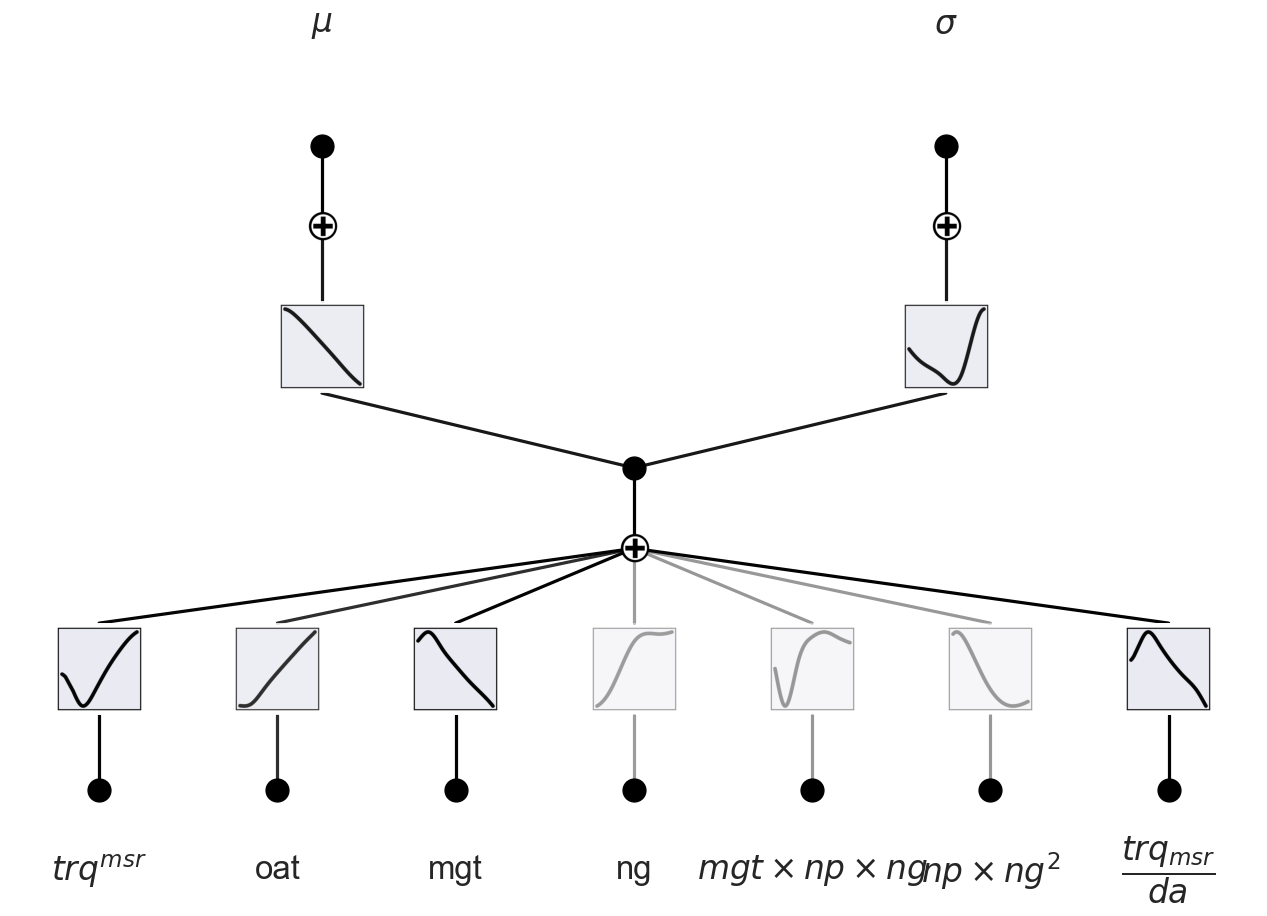

In [8]:
# 1s
pyKAN.plot(in_vars=list(map(to_latex,df_x.columns)))

### Visualizing the variance of the performance of the 10 trainings

Text(-3.615456994207282, 0.7, '$\\tilde{\\mu}_3$ = 0.184')

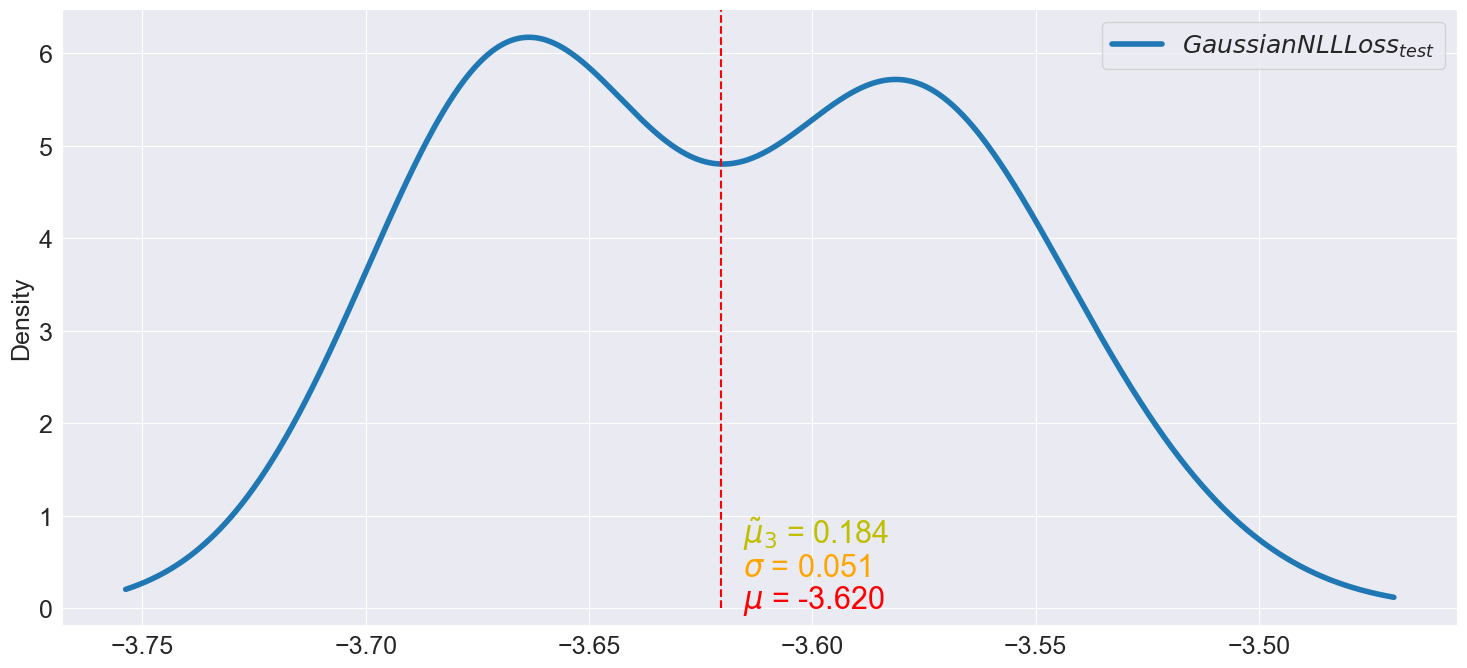

In [6]:
# 0s
result = pd.read_csv(f'results/small_09 March 25 12-23-01.csv').drop('answer_avg_variance', axis=1)
result['training'] = range(1, 11)
ax = result.plot(kind='kde', x='training', y='test_loss', figsize=(18, 8), linewidth=4,
                 label='$GaussianNLLLoss_{test}$')
mean = result['test_loss'].mean()
skew = result['test_loss'].skew()
std = result['test_loss'].std()
ax.add_line(Line2D([mean, mean], [0, 6.5], linestyle='--', color='red'))
ax.text(mean + 0.005, 0, f'$\\mu$ = {mean:.3f}', fontsize=22, c='r')
ax.text(mean + 0.005, 0.35, f'$\\sigma$ = {std:.3f}', fontsize=22, c='orange')
ax.text(mean + 0.005, 0.7, f'$\\tilde{"{"}\\mu{"}"}_3$ = {skew:.3f}', fontsize=22, c='y')

### Plotting an inference

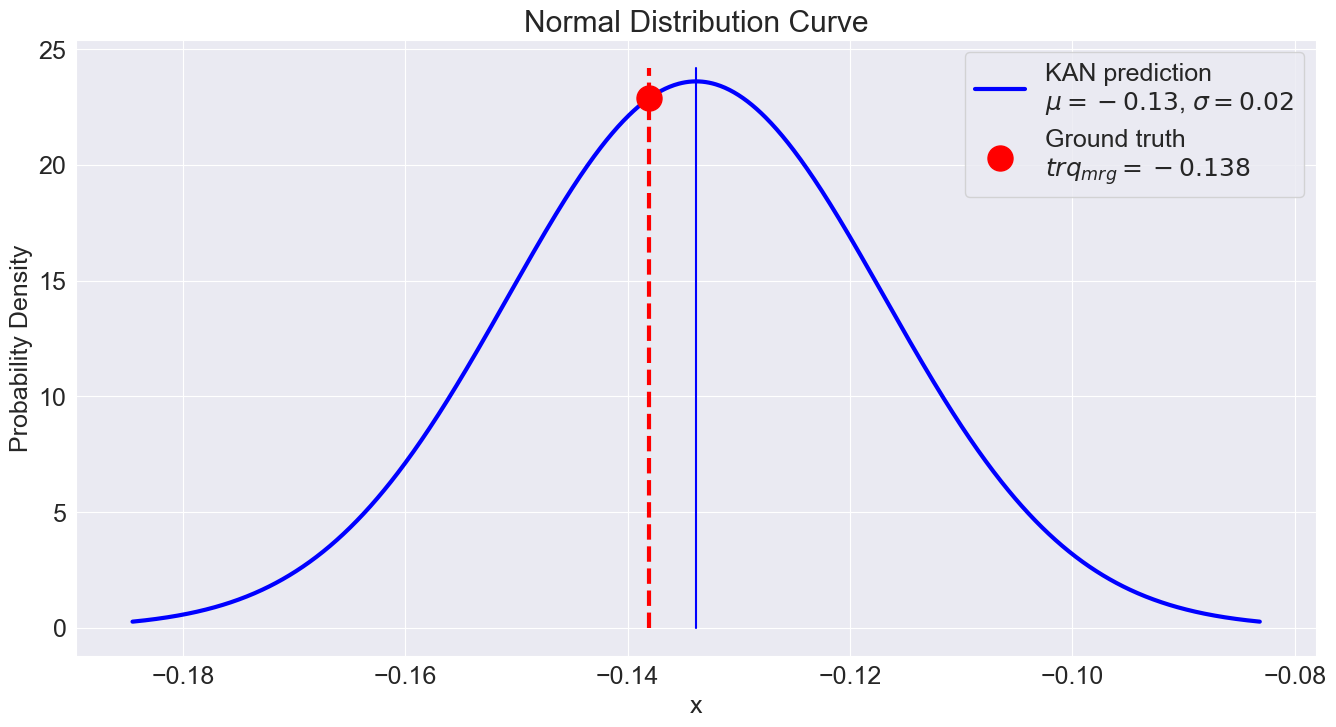

In [7]:
# 0s
trainset, validset, testset, _ = split_dataset(df_x, df_y['trq_target'], train_ratio=0.15, max=1, seed=1)
for i in range(100, 102, 2):
    mu, log_var = pyKAN(testset[0][i - 1:i + 1, ])
    var = torch.exp(log_var)
    mu = mu[0].cpu().item()
    var = var[0].cpu().item() ** 0.5
    ground_truth = testset[1][i - 1,].cpu().item()

    x = np.linspace(mu - 3 * var, mu + 3 * var, 1000)
    pdf = norm.pdf(x, mu, var)

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.plot(x, pdf, label=f'KAN prediction\n$\mu={mu:.2f}$, $\sigma={var:.2f}$', color='blue', linewidth=3)
    ax.add_line(Line2D([mu, mu], [0, pdf.max() * 1.025], linestyle='-', color='blue'))
    ax.add_line(Line2D([ground_truth, ground_truth], [0, pdf.max() * 1.025], linestyle='--', color='red', linewidth=3))
    ax.plot(ground_truth, norm.pdf(ground_truth, mu, var), 'ro',
            label=f'Ground truth\n$trq_{"{mrg}"}={ground_truth:.3f}$', markersize=18)

    plt.title('Normal Distribution Curve')
    plt.xlabel('x')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.show()

## Train the EfficientKAN

In [3]:
efficientKAN: PHMNetwork = EfficientKAN(layers=[len(df_x.columns), 1, 2], task='regression', device='cpu')

In [10]:
efficientKAN.load('torque_target_final')

Time 1/1===========================


100%|██████████| 23/23 [00:00<00:00, 52.23it/s, epoch=29, loss=-3.01, lr=0.0153]


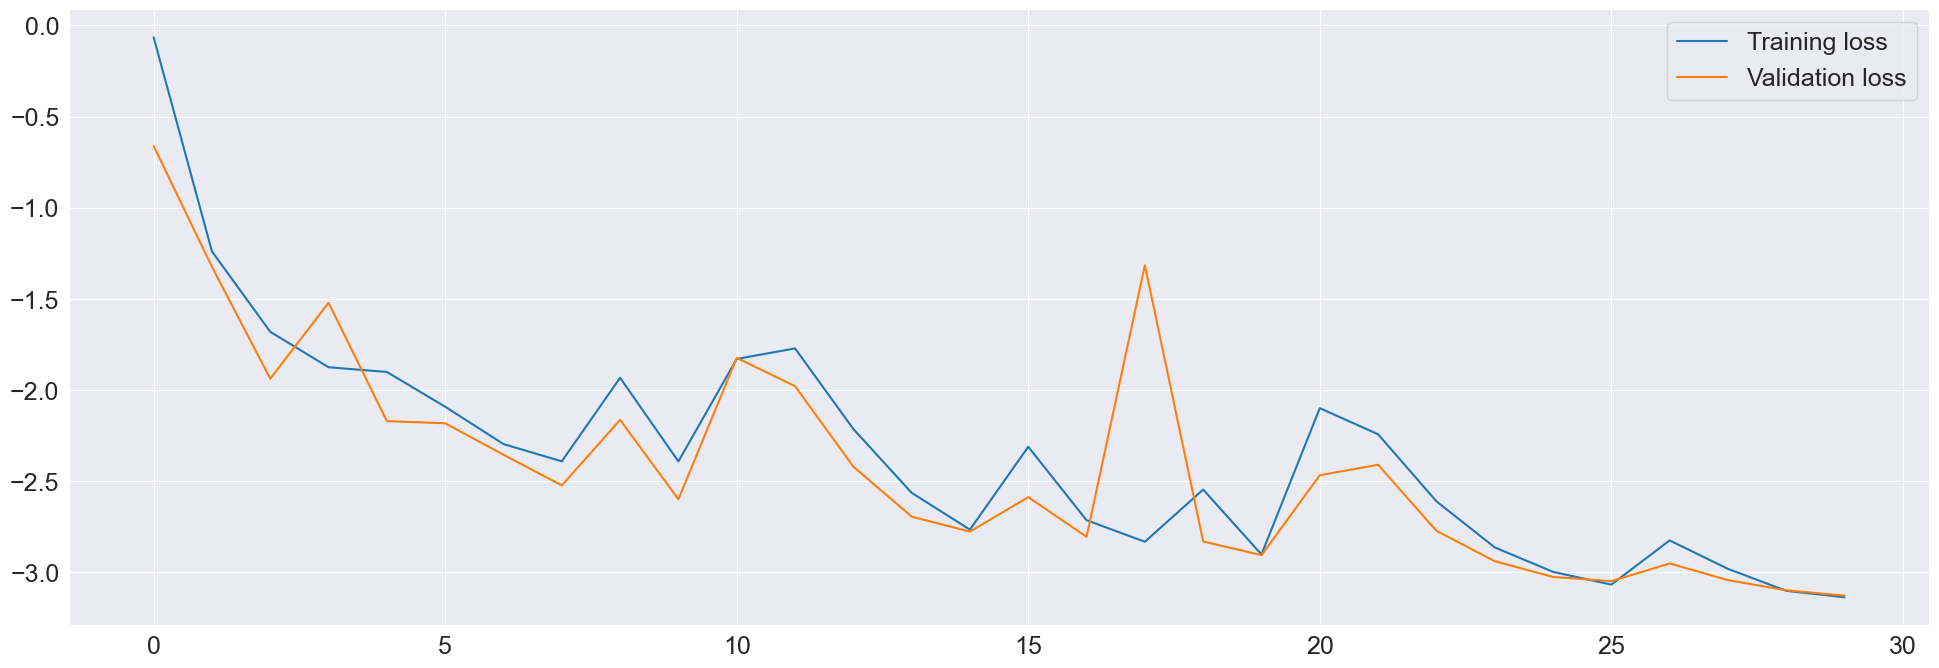

100%|██████████| 34/34 [00:00<00:00, 55.02it/s]


,test_loss
0,-3.102762


In [5]:
# 36s
efficientKAN.multi_train(df_x, df_y['trq_target'], epochs=30, times=1)

In [6]:
efficientKAN.save('torque_target_final')

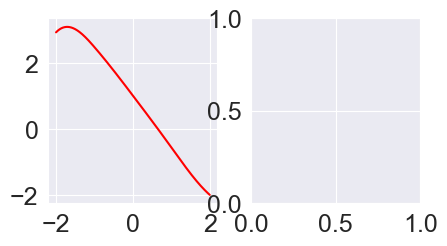

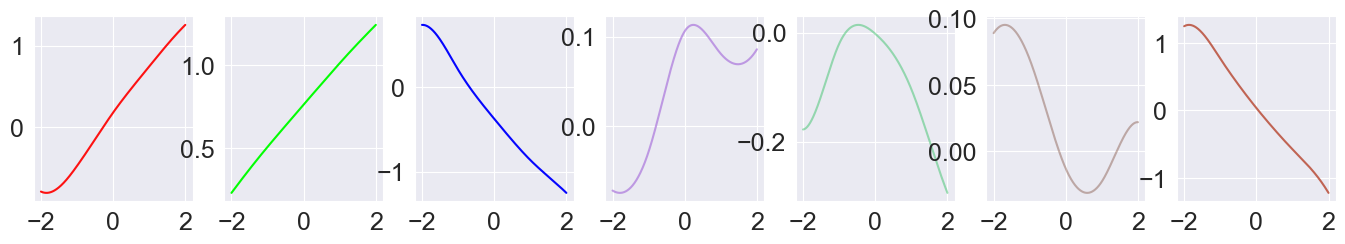

In [11]:
efficientKAN.plot(scale=1.2)

## Train the MLP

In [9]:
mlp: PHMNetwork = MLP(layers=[len(df_x.columns), 32, 32, 2], task='regression', device='cpu')

In [ ]:
mlp.load('torque_target_final')

Time 1/1===========================


100%|██████████| 23/23 [00:00<00:00, 222.24it/s, epoch=99, loss=-4.7, lr=0.000879] 


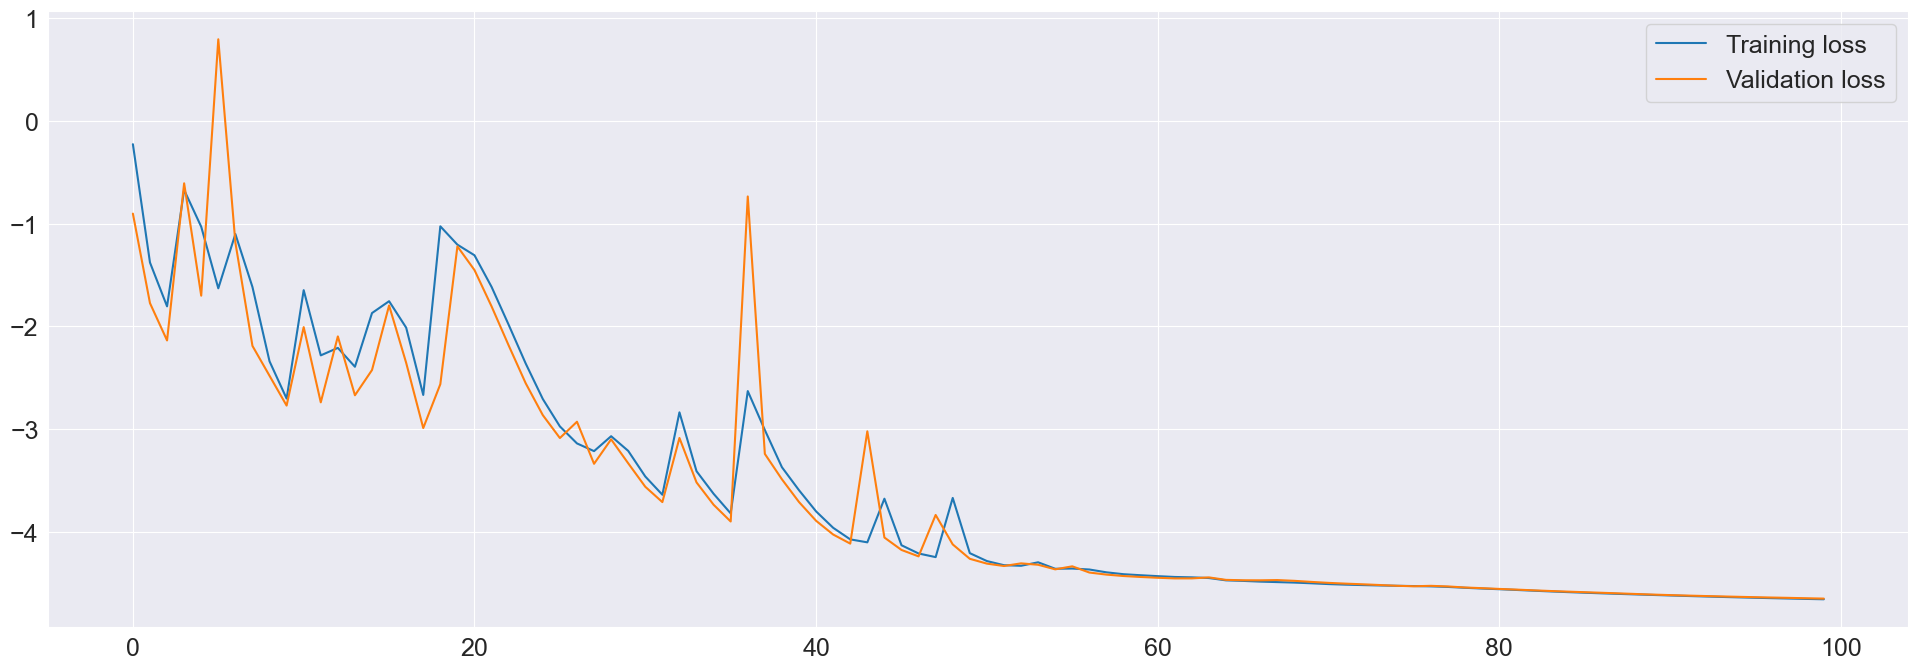

100%|██████████| 34/34 [00:00<00:00, 283.04it/s]


,test_loss
0,-4.649648


In [10]:
# 36s
mlp.multi_train(df_x, df_y['trq_target'], epochs=100, times=1)

In [11]:
mlp.save('torque_target_final')

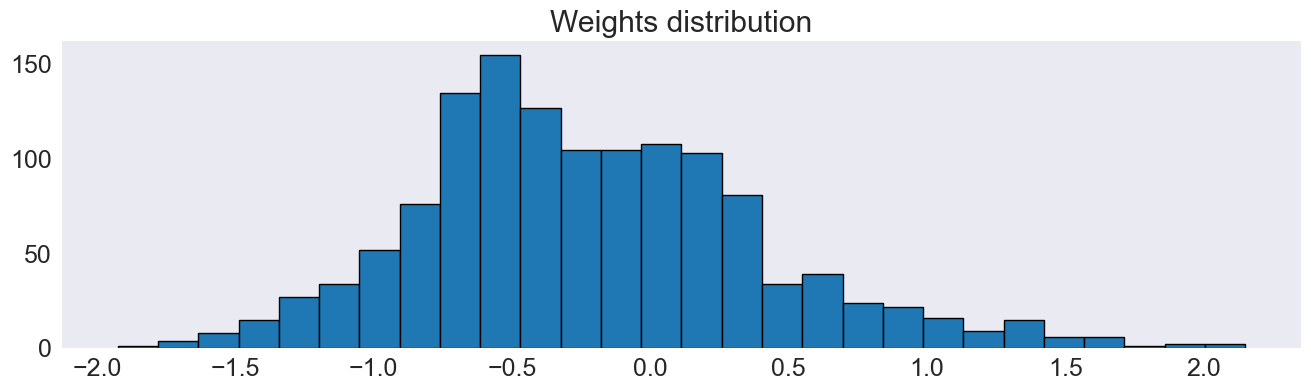

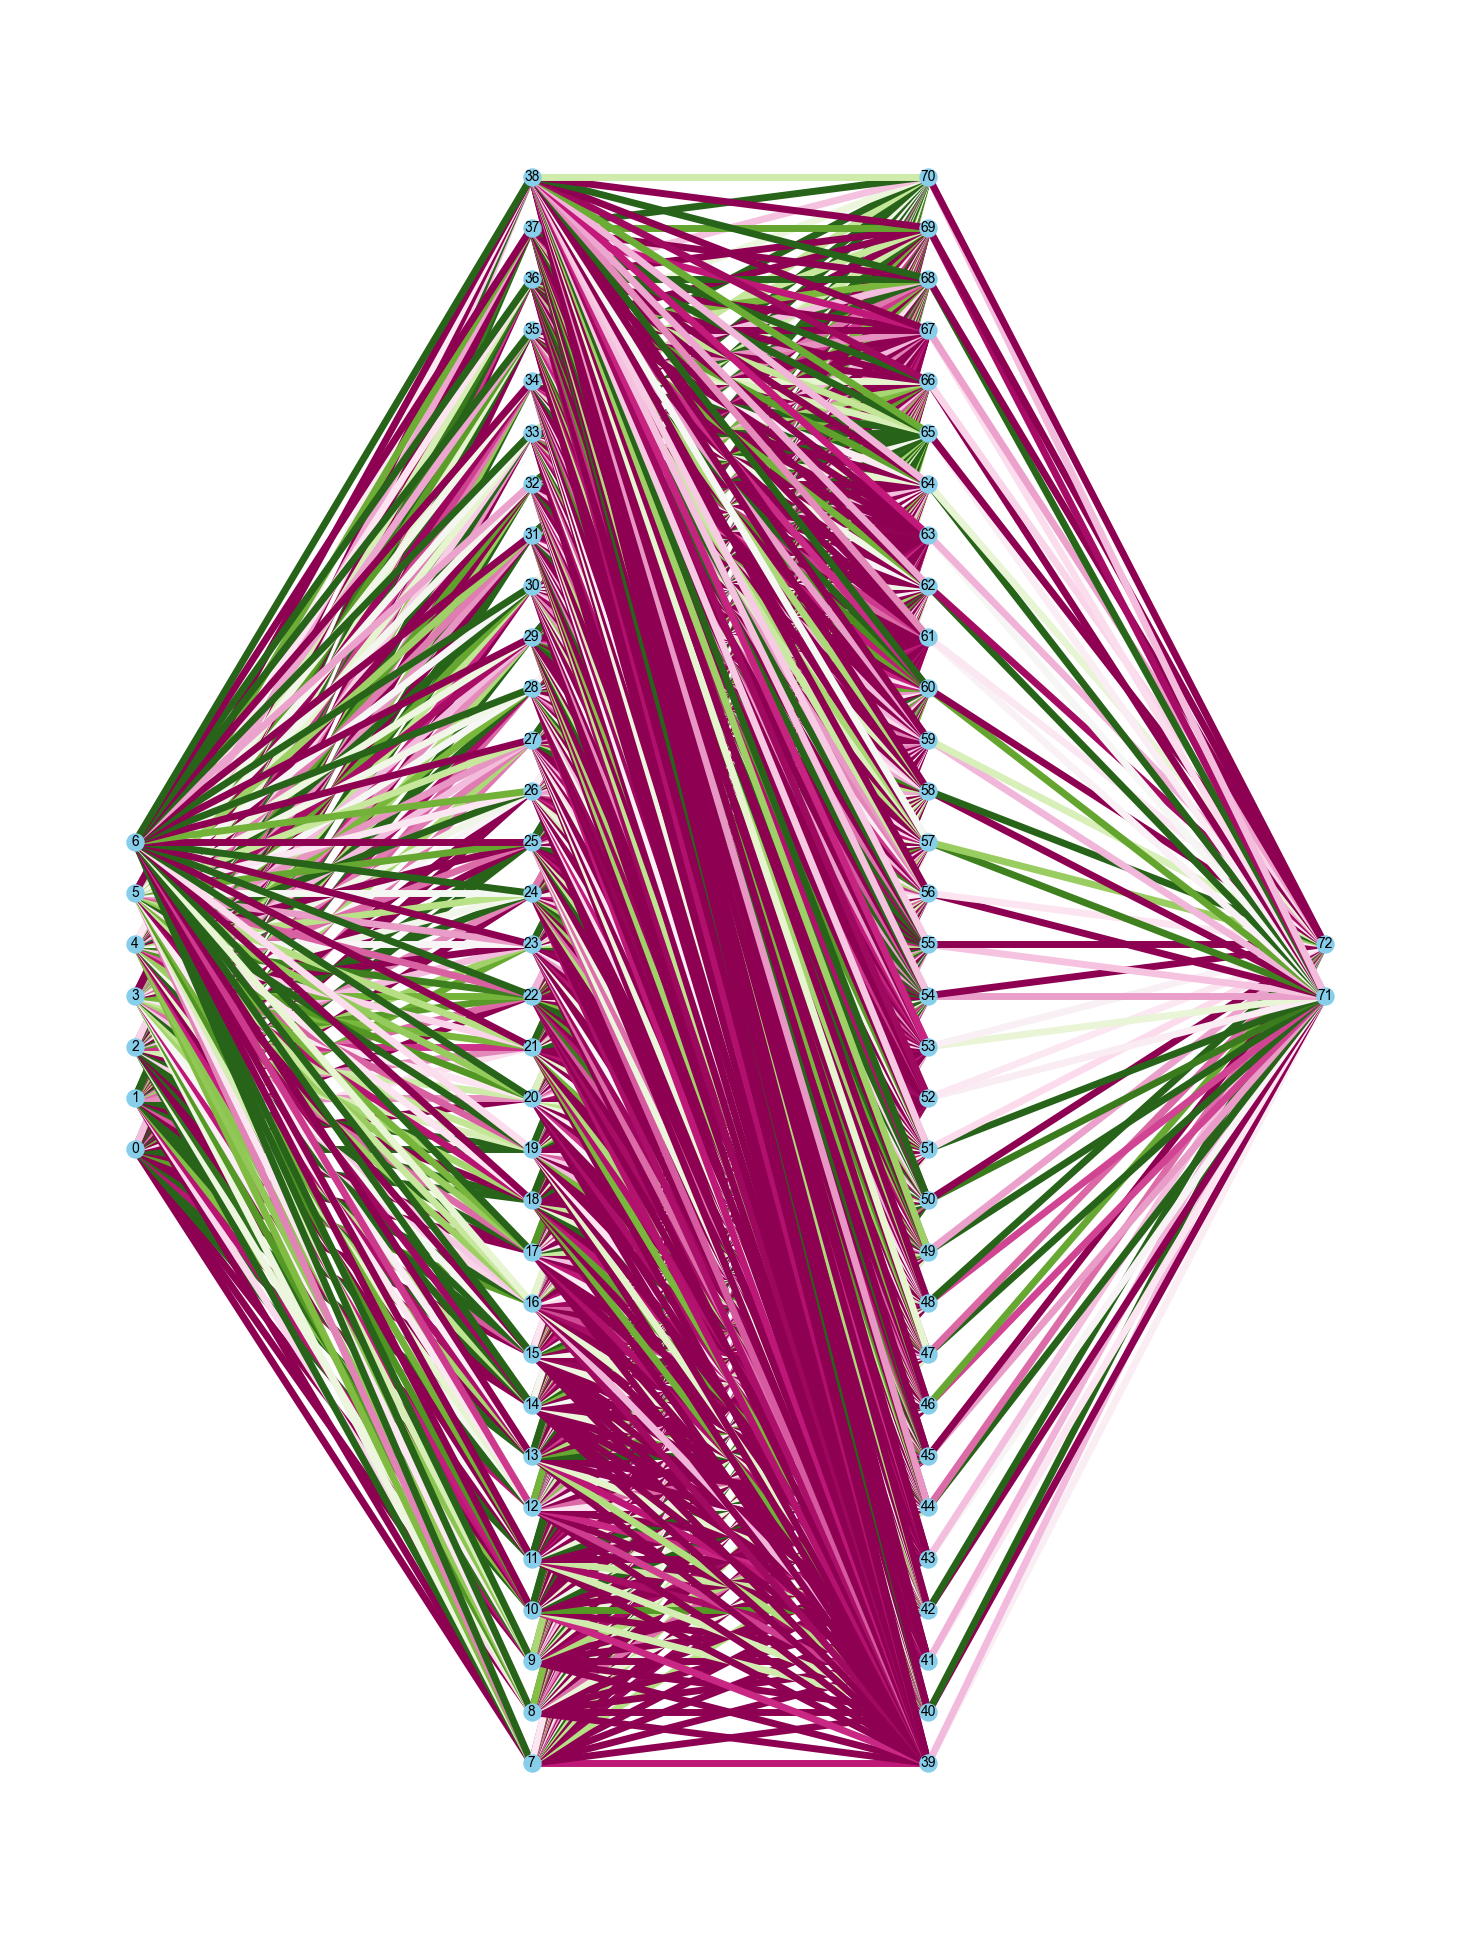

In [12]:
mlp.plot(scale=1.2)

Talk about interpretability... MLP might be accurate, but are fare less expressive than KAN!

### FLOPS calculation
See more on: https://arxiv.org/abs/2409.13550

In [13]:
with torch.cuda.device(0):
    flops, params = get_model_complexity_info(mlp, (len(df_x.columns),), as_strings=True)
    print(f"FLOPs: {flops}")
    print(f"Params: {params}")

MLP(
  1.38 k, 100.000% Params, 1.38 KMac, 100.000% MACs, 
  (criterion): GaussianNLLLoss(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
  (model): Sequential(
    1.38 k, 100.000% Params, 1.38 KMac, 100.000% MACs, 
    (0): Linear(256, 18.578% Params, 256.0 Mac, 18.578% MACs, in_features=7, out_features=32, bias=True)
    (1): Sigmoid(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (2): Linear(1.06 k, 76.633% Params, 1.06 KMac, 76.633% MACs, in_features=32, out_features=32, bias=True)
    (3): Sigmoid(0, 0.000% Params, 0.0 Mac, 0.000% MACs, )
    (4): Linear(66, 4.790% Params, 66.0 Mac, 4.790% MACs, in_features=32, out_features=2, bias=True)
  )
)
FLOPs: 1.38 KMac
Params: 1.38 k
